In [1]:
# Import Libraries and Modules
import pandas as pd
import re, string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import joblib


In [2]:
# Load the dataset
df = pd.read_csv("spam mail.csv")
df.head()


,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Rename the column
df.rename(columns={"Masseges:": "Messages"}, inplace=True)
df.columns = ["Category", "Messages"]

# Label each category
df["label_num"] = df["Category"].map({"ham": 0, "spam": 1})


In [4]:
# In-depth analysis of the dataset
print(df.shape)
print(df["Category"].value_counts())
print(df.isnull().sum())  # confirm no nulls

(5572, 3)
Category
ham     4825
spam     747
Name: count, dtype: int64
Category     0
Messages     0
label_num    0
dtype: int64


In [5]:
# Text Preprocessing
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [6]:
# Function to clean the text data
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"\d+", "", text)  # Remove numbers
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )  # Remove punctuation
    tokens = text.split()  # Tokenize the text
    tokens = [
        lemmatizer.lemmatize(w) for w in tokens if w not in stop_words
    ]  # Remove stop words and apply lemmatization
    return " ".join(tokens)


In [7]:
# Apply the cleaning function to the messages
df["clean_message"] = df["Messages"].apply(clean_text)
df[["Messages", "clean_message"]].head(3)

# Add a new column for message length
df["msg_length"] = df["clean_message"].apply(len)


In [8]:
# Prepare the data for modeling
X = df["clean_message"]
y = df["label_num"]

# Split the data into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# Train multiple models using Pipeline (TF-IDF + Model together)
models = {
    "Naive Bayes": Pipeline(
        [
            ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
            ("clf", MultinomialNB()),
        ]
    ),
    "Logistic Regression": Pipeline(
        [
            ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
        ]
    ),
    "Linear SVM": Pipeline(
        [
            ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
            ("clf", LinearSVC(class_weight="balanced", max_iter=1000)),
        ]
    ),
}

In [10]:
results = {}
for name, model in models.items():
    model.fit(X_train_raw, y_train)  # Fit pipeline directly

    # Predictions
    y_pred = model.predict(X_test_raw)

    # Handle probability / decision scores
    if hasattr(model.named_steps["clf"], "predict_proba"):
        y_proba = model.predict_proba(X_test_raw)[:, 1]
    else:
        y_proba = model.decision_function(X_test_raw)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store results
    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
    }


In [11]:
for model_name, metrics in results.items():
    print("---" * 10)
    print(f"{model_name}:")
    print("---" * 10)
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


------------------------------
Naive Bayes:
------------------------------
  accuracy: 0.9686
  precision: 0.9914
  recall: 0.7718
  roc_auc: 0.9802
------------------------------
Logistic Regression:
------------------------------
  accuracy: 0.9731
  precision: 0.8839
  recall: 0.9195
  roc_auc: 0.9835
------------------------------
Linear SVM:
------------------------------
  accuracy: 0.9839
  precision: 0.9580
  recall: 0.9195
  roc_auc: 0.9833


In [12]:
# Confusion Matrix and Classification Report for the models
for name, model in models.items():
    y_pred = model.predict(X_test_raw)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



--- Naive Bayes ---
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
[[965   1]
 [ 34 115]]

--- Logistic Regression ---
              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       966
        spam       0.88      0.92      0.90       149

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
[[948  18]
 [ 12 137]]

--- Linear SVM ---
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                  

In [13]:
# Perform Hyperparameter Tuning for Linear SVM
param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__loss": ["hinge", "squared_hinge"],
    "clf__max_iter": [1000, 2000],
}

# Use Pipeline to ensure that TF-IDF vectorization is included in the grid search
svm_pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("clf", LinearSVC(class_weight="balanced")),
    ]
)

In [14]:
# Define GridSearchCV with StratifiedKFold
grid_search_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=StratifiedKFold(
        n_splits=5, shuffle=True, random_state=28
    ),  # Use StratifiedKFold for better class balance in CV
    scoring="f1",  # Optimize for F1-score to balance precision and recall
    n_jobs=-1,
    verbose=1,
)

grid_search_svm.fit(X_train_raw, y_train)

# Best model info
best_svm = grid_search_svm.best_estimator_
print(f"\nBest SVM Params: {grid_search_svm.best_params_}")
print(f"Best CV F1-Score: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best SVM Params: {'clf__C': 1, 'clf__loss': 'squared_hinge', 'clf__max_iter': 1000}
Best CV F1-Score: 0.9202


In [15]:
# Predictions
y_pred_svm = best_svm.predict(X_test_raw)
y_score_svm = best_svm.decision_function(X_test_raw)

# Metrics
print("\nTuned Linear SVM Performance:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_svm):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_score_svm):.4f}")



Tuned Linear SVM Performance:
Accuracy : 0.9839
Precision: 0.9580
Recall   : 0.9195
F1-Score : 0.9384
ROC AUC  : 0.9833


In [16]:
# Classification Report of Tuned Linear SVM
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["ham", "spam"]))



Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



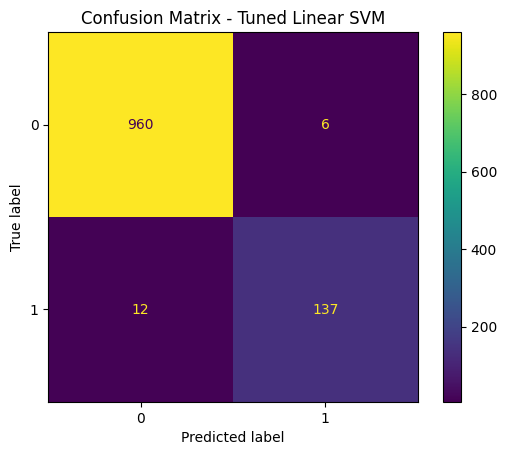

In [17]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_svm,
    X_test_raw,
    y_test,
)

plt.title("Confusion Matrix - Tuned Linear SVM")
plt.show()


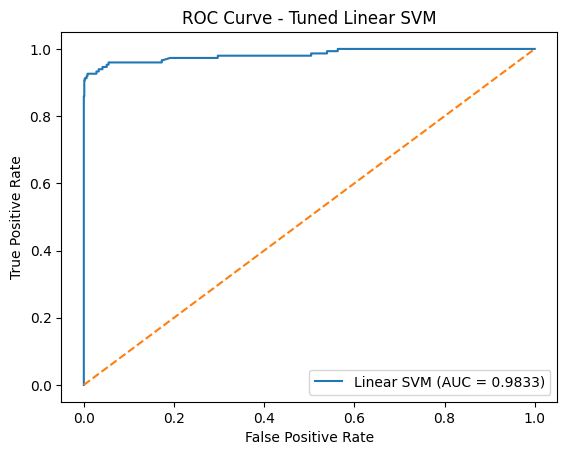

In [18]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

# Get decision scores (since LinearSVC doesn't have predict_proba)
y_score = best_svm.decision_function(X_test_raw)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"Linear SVM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Linear SVM")
plt.legend(loc="lower right")

plt.show()

In [19]:
# Save the final tuned model (Pipeline)
joblib.dump(best_svm, "spam_classifier_pipeline.pkl")

print("Model saved successfully!")


Model saved successfully!
